# citegraph quickstart

Two ways to run the pipeline on a folder of PDFs:

1. **All at once** — `pipe.run()` does every stage end-to-end.
2. **Step by step** — call each stage method, inspect the artifact on disk, decide whether to continue.

Both modes share the same `out_dir`, so you can mix and match: kick off `run()` once and then re-run an individual stage to iterate on it.

Set `GOOGLE_API_KEY` in your environment (or in a `.env` file in the current working directory) before running the cells below.

In [22]:
import citegraph, inspect
print(inspect.getfile(citegraph)) 

/Users/yabra/repos/citegraph/src/citegraph/__init__.py


In [23]:
from pathlib import Path

import pandas as pd

from citegraph import Pipeline

PDF_DIR = Path("/Users/yabra/Dropbox/Consultoria/Maria/data_papers4/")  # adapt to your project layout
OUT_DIR = Path("../out")

pipe = Pipeline(pdf_dir=PDF_DIR, 
                out_dir=OUT_DIR,
                model='gemini-3.1-flash-lite',
                enrich=False,
                recursive=True,
                show_progress=True,
                ocr=True)

## Mode A — run the whole pipeline

Use this when you trust the defaults and just want the three CSVs.
Skip this section entirely if you'd rather drive the pipeline stage-by-stage in Mode B.

In [ ]:
result = pipe.run()
print(
    f"papers={len(result.papers)}, "
    f"references={len(result.references)}, "
    f"edges={len(result.graph)}"
)

In [ ]:
result.papers.head()

In [ ]:
result.references.head()

## Mode B — progressive, one stage at a time

Each stage method writes its output to `OUT_DIR` and reads its input from disk if you call it with no arguments. So you can stop after any cell, eyeball the artifact, edit it by hand if you want, and only continue when you're happy.

The pipeline layout under `OUT_DIR`:

```
out/
  markdown/                 # stage 1: docling output, one .md per PDF
  metadata/<paper>.json     # stage 2: per-paper Gemini metadata
  references/<paper>.json   # stage 3: per-paper Gemini references
  papers.csv                # stage 2 aggregated
  references_raw.csv        # stage 3 aggregated
  references.csv            # stage 4 deduplicated
  citation_graph.csv        # stage 4 edges
```

Re-running a stage reuses any per-paper cache files it already wrote, so iterating is cheap.

### Stage 1 — PDFs ➜ markdown

`docling` is slow on first run; cached markdown is reused on subsequent calls. Pass `overwrite_markdown=True` on the `Pipeline` constructor if you need to force a re-conversion.

In [24]:
markdown_paths = pipe.convert_pdfs()
print(f"{len(markdown_paths)} markdown files in {pipe.layout.markdown_dir}")
for p in markdown_paths[:5]:
    print(" ", p.name)

Output()

91 markdown files in ../out/markdown
  Cardenas__Communication_and_Cooperation_in_a_Common_Pool_Res.md
  Cardenas__Discrimination-in-the-Provision-of-Social-Services-to-the-Poor-A-Field-Experimental-Study.md
  Cardenas__Dynamics_of_Rules_and_Resources_Three_New_Field_Ex.md
  Cardenas__MarketsReligionCommunity-2010.md
  Cardenas__Rethinking_Local_Commons_Dilemmas_Lessons_from_Experimental_Economics_in_the_Field.md


In [25]:
# # Spot-check the first markdown file before continuing.
# if markdown_paths:
#     print(markdown_paths[0].read_text()[:1500])

### Stage 2 — markdown ➜ paper metadata

Calls Gemini once per paper. Per-paper JSON is cached under `OUT_DIR/metadata/`, so re-running this cell after editing a single cached JSON file will pick up your edits and rewrite `papers.csv`.

In [26]:
papers = pipe.extract_paper_metadata()
papers.head()

Output()

,Title,Authors_List,Journal,Year,Authors,source_file,id
0,COMMUNICATION AND COOPERATION IN A COMMON-POOL...,"[Juan-Camilo Cardenas, T. K. Ahn, Elinor Ostrom]",Workshop in Political Theory and Policy Analysis,2003,"Juan-Camilo Cardenas, T. K. Ahn, Elinor Ostrom",Cardenas__Communication_and_Cooperation_in_a_C...,p-cardenas-2003-communication-and-cooperation-...
1,Discrimination in the Provision of Social Serv...,"[Juan-Camilo Cárdenas, Natalia Candelo, Alejan...",Research Network Working paper,2008,"Juan-Camilo Cárdenas, Natalia Candelo, Alejand...",Cardenas__Discrimination-in-the-Provision-of-S...,p-rdenas-2008-discrimination-in-the-provision-...
2,Dynamics of Rules and Resources: Three New Fie...,"[Juan-Camilo Cardenas, Marco Janssen, Francois...",Handbook on Experimental Economics and the Env...,2008,"Juan-Camilo Cardenas, Marco Janssen, Francois ...",Cardenas__Dynamics_of_Rules_and_Resources_Thre...,p-cardenas-2008-dynamics-of-rules-and-resource...
3,"Markets, Religion, Community Size, and the Evo...","[Joseph Henrich, Jean Ensminger, Richard McElr...",Science,2010,"Joseph Henrich, Jean Ensminger, Richard McElre...",Cardenas__MarketsReligionCommunity-2010.md,p-henrich-2010-markets-religion-community-size...
4,Rethinking Local Commons Dilemmas: Lessons fro...,[Juan-Camilo Cardenas],"Facultad de Estudios Ambientales y Rurales, Un...",2000,Juan-Camilo Cardenas,Cardenas__Rethinking_Local_Commons_Dilemmas_Le...,p-cardenas-2000-rethinking-local-commons-dilem...


In [27]:
papers.shape

(91, 7)

### Stage 3 — markdown ➜ per-paper references

Also Gemini-driven, also cached per paper under `OUT_DIR/references/`. Output is the long-format `references_raw.csv` with one row per (citing_paper, raw_reference).

In [28]:
raw_refs = pipe.extract_paper_references()
print(f"{len(raw_refs)} raw references across {raw_refs['citing_id'].nunique()} papers")
raw_refs.head()

Output()

4115 raw references across 91 papers


,Title,Authors_List,Journal,Year,Authors,citing_id
0,"Signals, Symbols, and Human Cooperation.","[Ahn, T.K., Marco A. Janssen, Elinor Ostrom]",Working paper W03-1. Bloomington: Indiana Univ...,2003,"Ahn, T.K., Marco A. Janssen, Elinor Ostrom",p-cardenas-2003-communication-and-cooperation-...
1,"Uncertainty, Evolution, and Economic Theory.","[Alchian, Armen A.]",Journal of Political Economy,1950,"Alchian, Armen A.",p-cardenas-2003-communication-and-cooperation-...
2,Communication and Punishment in Voluntary Cont...,"[Bochet, Oliver, Talbot Page, Louis Putterman]","Working paper. Providence, RI: Brown University",2002,"Bochet, Oliver, Talbot Page, Louis Putterman",p-cardenas-2003-communication-and-cooperation-...
3,The Sound of Silence in Prisoner's Dilemma and...,"[Bohnet, Iris, Bruno S. Frey]",Journal of Economic Behavior and Organization,1999,"Bohnet, Iris, Bruno S. Frey",p-cardenas-2003-communication-and-cooperation-...
4,"ERC: A Theory of Equity, Reciprocity, and Comp...","[Bolton, Gary E., Axel Ockenfels]",American Economic Review,2000,"Bolton, Gary E., Axel Ockenfels",p-cardenas-2003-communication-and-cooperation-...


In [29]:
raw_refs

,Title,Authors_List,Journal,Year,Authors,citing_id
0,"Signals, Symbols, and Human Cooperation.","[Ahn, T.K., Marco A. Janssen, Elinor Ostrom]",Working paper W03-1. Bloomington: Indiana Univ...,2003,"Ahn, T.K., Marco A. Janssen, Elinor Ostrom",p-cardenas-2003-communication-and-cooperation-...
1,"Uncertainty, Evolution, and Economic Theory.","[Alchian, Armen A.]",Journal of Political Economy,1950,"Alchian, Armen A.",p-cardenas-2003-communication-and-cooperation-...
2,Communication and Punishment in Voluntary Cont...,"[Bochet, Oliver, Talbot Page, Louis Putterman]","Working paper. Providence, RI: Brown University",2002,"Bochet, Oliver, Talbot Page, Louis Putterman",p-cardenas-2003-communication-and-cooperation-...
3,The Sound of Silence in Prisoner's Dilemma and...,"[Bohnet, Iris, Bruno S. Frey]",Journal of Economic Behavior and Organization,1999,"Bohnet, Iris, Bruno S. Frey",p-cardenas-2003-communication-and-cooperation-...
4,"ERC: A Theory of Equity, Reciprocity, and Comp...","[Bolton, Gary E., Axel Ockenfels]",American Economic Review,2000,"Bolton, Gary E., Axel Ockenfels",p-cardenas-2003-communication-and-cooperation-...
...,...,...,...,...,...,...
4110,Measuring conditional cooperation: A replicati...,"[Herrmann, B., C. Thöni]",Experimental Economics,2009,"Herrmann, B., C. Thöni",p-palacio-2010-formal-and-informal-regulations...
4111,Does stake size matter for cooperation and pun...,"[Kocher, M., P. Martinsson, M. Visser]",Economics Letters,2008,"Kocher, M., P. Martinsson, M. Visser",p-palacio-2010-formal-and-informal-regulations...
4112,Conditional cooperation on three continents,"[Kocher, M., T. Cherry, S. Kroll, R. Netzer, M...",Economics Letters,2008,"Kocher, M., T. Cherry, S. Kroll, R. Netzer, M....",p-palacio-2010-formal-and-informal-regulations...
4113,Inequality and group participation: theory and...,"[La Ferrara, E.]",Journal of Public Economics,2002,"La Ferrara, E.",p-palacio-2010-formal-and-informal-regulations...


### Stage 4 — fuzzy dedup + citation graph

Pure-Python; no network. The dedup config (weights, threshold, year window) is what you'll most often want to tweak between iterations — pass a custom `DedupConfig` to `Pipeline(..., dedup_config=...)` and rerun this cell.

In [30]:
references, graph = pipe.deduplicate()
print(f"{len(raw_refs)} raw -> {len(references)} unique references, {len(graph)} edges")
references.head()

Output()

4115 raw -> 2917 unique references, 4104 edges


,Authors,Journal,Title,Year
id,,,,
r-ahn-2003-signals-symbols-and-human-cooperation,"Ahn, T.K., Marco A. Janssen, Elinor Ostrom",Working paper W03-1. Bloomington: Indiana Univ...,"Signals, Symbols, and Human Cooperation.",2003
r-alchian-1950-uncertainty-evolution-and-economic,"Alchian, Armen A.",Journal of Political Economy,"Uncertainty, Evolution, and Economic Theory.",1950
r-bochet-2002-communication-and-punishment-in,"Bochet, Oliver, Talbot Page, Louis Putterman","Working paper. Providence, RI: Brown University",Communication and Punishment in Voluntary Cont...,2002
r-bohnet-1999-the-sound-of-silence-in-prisoner-s-and,"Bohnet, Iris, Bruno S. Frey",Journal of Economic Behavior and Organization,The Sound of Silence in Prisoner's Dilemma and...,1999
r-bolton-2000-erc-a-theory-of-equity-reciprocity-and,"Bolton, Gary E., Axel Ockenfels",American Economic Review,"ERC: A Theory of Equity, Reciprocity, and Comp...",2000


In [31]:
references

,Authors,Journal,Title,Year
id,,,,
r-ahn-2003-signals-symbols-and-human-cooperation,"Ahn, T.K., Marco A. Janssen, Elinor Ostrom",Working paper W03-1. Bloomington: Indiana Univ...,"Signals, Symbols, and Human Cooperation.",2003
r-alchian-1950-uncertainty-evolution-and-economic,"Alchian, Armen A.",Journal of Political Economy,"Uncertainty, Evolution, and Economic Theory.",1950
r-bochet-2002-communication-and-punishment-in,"Bochet, Oliver, Talbot Page, Louis Putterman","Working paper. Providence, RI: Brown University",Communication and Punishment in Voluntary Cont...,2002
r-bohnet-1999-the-sound-of-silence-in-prisoner-s-and,"Bohnet, Iris, Bruno S. Frey",Journal of Economic Behavior and Organization,The Sound of Silence in Prisoner's Dilemma and...,1999
r-bolton-2000-erc-a-theory-of-equity-reciprocity-and,"Bolton, Gary E., Axel Ockenfels",American Economic Review,"ERC: A Theory of Equity, Reciprocity, and Comp...",2000
...,...,...,...,...
r-gächter-2007-conditional-cooperation-behavioural-from,"Gächter, S.",Psychology and economics: A promising new cros...,Conditional cooperation: Behavioural regularit...,2007
r-gächter-2006-the-limits-of-self-governance-in-the-of,"Gächter, S., B. Herrmann","Working Paper 2006-13, University of Nottingham",The limits of self-governance in the presence ...,2006
r-kocher-2008-does-stake-size-matter-for-cooperation,"Kocher, M., P. Martinsson, M. Visser",Economics Letters,Does stake size matter for cooperation and pun...,2008


In [32]:
graph

,citing_id,cited_id
0,p-cardenas-2003-communication-and-cooperation-...,r-ahn-2003-signals-symbols-and-human-cooperation
1,p-cardenas-2003-communication-and-cooperation-...,r-alchian-1950-uncertainty-evolution-and-economic
2,p-cardenas-2003-communication-and-cooperation-...,r-bochet-2002-communication-and-punishment-in
3,p-cardenas-2003-communication-and-cooperation-...,r-bohnet-1999-the-sound-of-silence-in-prisoner...
4,p-cardenas-2003-communication-and-cooperation-...,r-bolton-2000-erc-a-theory-of-equity-reciproci...
...,...,...
4099,p-palacio-2010-formal-and-informal-regulations...,r-benediktherrmann-2009-measuring-conditional-...
4100,p-palacio-2010-formal-and-informal-regulations...,r-kocher-2008-does-stake-size-matter-for-coope...
4101,p-palacio-2010-formal-and-informal-regulations...,r-martingkocher-2008-conditional-cooperation-o...
4102,p-palacio-2010-formal-and-informal-regulations...,r-laferrara-2002-inequality-and-group-particip...


### Stage 5 — optional CrossRef / OpenAlex enrichment

Skip unless you installed the `[crossref]` extra and want DOIs filled in. Construct a separate `Pipeline` with `enrich=True` (or set the flag on `pipe`) before calling.

In [33]:
# pipe_enriched = Pipeline(pdf_dir=PDF_DIR, out_dir=OUT_DIR, enrich=True)
# references = pipe_enriched.maybe_enrich()
# references.head()

### Stage 6 — author normalization

Clusters every author across the corpus into canonical records, so "Cardenas, J-C", "Cardenas, Juan Camilo", "Cardenas, Juan-Camilo", and "Cárdenas, J.C." count as one person. Writes `authors.csv` and `author_citations.csv` to `OUT_DIR`.

The default `merge_mode="strict"` is precision-first: it merges initial-only records into a full-name anchor only when the initial is unambiguous. Pass `author_config=AuthorClusterConfig(merge_mode="loose")` on the `Pipeline` constructor to collapse purely by `(surname, first_initial)` instead. Low-confidence clusters (initial-only with several citations and no external id) are listed in `out_dir/author_review.json`. To force a merge by hand, drop a `cluster_id,canonical_id` CSV at `out_dir/author_aliases.csv` and re-run this cell.

In [35]:
authors_df, citations_df = pipe.normalize_authors()
print(
    f"{len(citations_df)} author occurrences -> "
    f"{len(authors_df)} canonical authors"
)
authors_df.head(15)

AttributeError: 'Pipeline' object has no attribute 'normalize_authors'

## Analysis — top-cited references

Works against either mode's output (the artifacts on disk are the same).
If you only ran Mode B, load the CSVs from disk first.

In [12]:
# Load from disk so this cell works regardless of which mode you ran above.
references = pd.read_csv(pipe.layout.references_csv, index_col="id")
graph = pd.read_csv(pipe.layout.graph_csv)

top = (
    graph.groupby("cited_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)
references.loc[top.index].assign(citations=top)

,Authors,Journal,Title,Year,citations
cited_id,,,,,
r-ostrom-1994-rules-games-and-common-pool-resources,"Ostrom, Elinor, Roy Gardner, James Walker",Ann Arbor: University of Michigan Press,"Rules, Games, and Common-Pool Resources.",1994,27
r-ledyard-1995-public-goods-a-survey-of-experimental,"Ledyard, John O.","The Handbook of Experimental Economics, ed. Jo...",Public Goods: A Survey of Experimental Research.,1995,27
r-cardenas-2000-local-environmental-control-and-crowding,"Cardenas, Juan-Camilo, Stranlund, John K., Wil...",World Development,Local Environmental Control and Institutional ...,2000,26
r-ostrom-1990-governing-the-commons-the-evolution-of,"Ostrom, Elinor",Cambridge University Press,Governing the Commons: The evolution of instit...,1990,23
r-ostrom-1998-a-behavioral-approach-to-the-rational-of,"Ostrom, Elinor",American Political Science Review,A Behavioral Approach to the Rational Choice T...,1998,22
r-harrison-2004-field-experiments,"Harrison, G., List, J.",Journal of Economic Literature,Field experiments,2004,22
r-ostrom-2000-collective-action-and-the-evolution-of,"Ostrom, E.",J. Ecol. Perspect.,Collective action and the evolution of social ...,2000,15
r-hardin-1968-the-tragedy-of-the-commons,"Hardin, Garret",Science,The Tragedy of the Commons,1968,15
r-cardenas-2003-real-wealth-and-experimental-cooperation,"Cardenas, Juan Camilo",Journal of Development Economics,Real Wealth and Experimental Cooperation: Evid...,2003,14


In [14]:
# print all columns (with full text) for a selected row
row = 3
references.loc[top.index].assign(citations=top).iloc[row]

Authors                                         Ostrom, Elinor
Journal                             Cambridge University Press
Title        Governing the Commons: The evolution of instit...
Year                                                      1990
citations                                                   23
Name: r-ostrom-1990-governing-the-commons-the-evolution-of, dtype: object

## CitationGraph — queryable view

`CitationGraph` wraps the three output CSVs into a single queryable object.  
Build it from `out_dir` — no pipeline object needed after the first run.

In [15]:
from citegraph import CitationGraph

g = CitationGraph.from_out_dir(OUT_DIR)
print(g)

g.top_cited(10)

<CitationGraph: 91 papers, 2917 references, 4104 edges>


,Authors,Journal,Title,Year,citation_count
id,,,,,
r-ledyard-1995-public-goods-a-survey-of-experimental,"Ledyard, John O.","The Handbook of Experimental Economics, ed. Jo...",Public Goods: A Survey of Experimental Research.,1995,27
r-ostrom-1994-rules-games-and-common-pool-resources,"Ostrom, Elinor, Roy Gardner, James Walker",Ann Arbor: University of Michigan Press,"Rules, Games, and Common-Pool Resources.",1994,27
r-cardenas-2000-local-environmental-control-and-crowding,"Cardenas, Juan-Camilo, Stranlund, John K., Wil...",World Development,Local Environmental Control and Institutional ...,2000,26
r-ostrom-1990-governing-the-commons-the-evolution-of,"Ostrom, Elinor",Cambridge University Press,Governing the Commons: The evolution of instit...,1990,23
r-ostrom-1998-a-behavioral-approach-to-the-rational-of,"Ostrom, Elinor",American Political Science Review,A Behavioral Approach to the Rational Choice T...,1998,22
r-harrison-2004-field-experiments,"Harrison, G., List, J.",Journal of Economic Literature,Field experiments,2004,22
r-hardin-1968-the-tragedy-of-the-commons,"Hardin, Garret",Science,The Tragedy of the Commons,1968,15
r-ostrom-2000-collective-action-and-the-evolution-of,"Ostrom, E.",J. Ecol. Perspect.,Collective action and the evolution of social ...,2000,15
r-cardenas-2003-real-wealth-and-experimental-cooperation,"Cardenas, Juan Camilo",Journal of Development Economics,Real Wealth and Experimental Cooperation: Evid...,2003,14


### Paper-level queries

`cited_by(paper_id)` returns every reference a source paper cites.  
`citers_of(reference_id)` returns every source paper that cites a given reference.

In [16]:
sample_paper_id = g.papers["id"].iloc[0]
print(f"References cited by:\n  {sample_paper_id}\n")
g.cited_by(sample_paper_id)

References cited by:
  p-cardenas-2003-communication-and-cooperation-in-a-pool



,Authors,Journal,Title,Year
id,,,,
r-ahn-2003-signals-symbols-and-human-cooperation,"Ahn, T.K., Marco A. Janssen, Elinor Ostrom",Working paper W03-1. Bloomington: Indiana Univ...,"Signals, Symbols, and Human Cooperation.",2003
r-alchian-1950-uncertainty-evolution-and-economic,"Alchian, Armen A.",Journal of Political Economy,"Uncertainty, Evolution, and Economic Theory.",1950
r-bochet-2002-communication-and-punishment-in,"Bochet, Oliver, Talbot Page, Louis Putterman","Working paper. Providence, RI: Brown University",Communication and Punishment in Voluntary Cont...,2002
r-bohnet-1999-the-sound-of-silence-in-prisoner-s-and,"Bohnet, Iris, Bruno S. Frey",Journal of Economic Behavior and Organization,The Sound of Silence in Prisoner's Dilemma and...,1999
r-bolton-2000-erc-a-theory-of-equity-reciprocity-and,"Bolton, Gary E., Axel Ockenfels",American Economic Review,"ERC: A Theory of Equity, Reciprocity, and Comp...",2000
r-bouas-1996-group-discussion-and-cooperation-in,"Bouas, K. S., S. S. Komorita",Personality and Social Psychology Bulletin,Group Discussion and Cooperation in Social Dil...,1996
r-brosig-2002-identifying-cooperative-behavior-some-in,"Brosig, Jeannete",Journal of Economic Behavior & Organization,Identifying Cooperative Behavior: Some Experim...,2002
r-camerer-2003-behavioral-game-theory-experiments-in,"Camerer, Colin F.",Princeton University Press,Behavioral Game Theory: Experiments in Strateg...,2003
r-cardenas-2003-bringing-the-lab-to-the-field-more-than,"Cardenas, Juan Camilo",International Meeting of the Economic Science ...,Bringing the Lab to the Field: More Than Chang...,2003


In [17]:
top_ref_id = g.top_cited(1).index[0]
print(f"Source papers that cite:\n  {top_ref_id}\n")
g.citers_of(top_ref_id)

Source papers that cite:
  r-ostrom-1994-rules-games-and-common-pool-resources



,Title,Authors_List,Journal,Year,Authors,source_file,id
0,COMMUNICATION AND COOPERATION IN A COMMON-POOL...,"['Juan-Camilo Cardenas', 'T. K. Ahn', 'Elinor ...",Workshop in Political Theory and Policy Analysis,2003,"Juan-Camilo Cardenas, T. K. Ahn, Elinor Ostrom",Cardenas__Communication_and_Cooperation_in_a_C...,p-cardenas-2003-communication-and-cooperation-...
4,Rethinking Local Commons Dilemmas: Lessons fro...,['Juan-Camilo Cardenas'],"Facultad de Estudios Ambientales y Rurales, Un...",2000,Juan-Camilo Cardenas,Cardenas__Rethinking_Local_Commons_Dilemmas_Le...,p-cardenas-2000-rethinking-local-commons-dilem...
6,Social Learning through Economic Games in the ...,"['Adriana Bernal', 'Juan-Camilo Cárdenas', 'La...",Unknown,2017,"Adriana Bernal, Juan-Camilo Cárdenas, Laia Dom...",Cardenas__Social_Learning_through_Economic_Gam...,p-bernal-2017-social-learning-through-economic...
8,Collective action for watershed management: fi...,"['JUAN CAMILO CARDENAS', 'LUZ ANGELA RODRIGUEZ...",Environment and Development Economics,2010,"JUAN CAMILO CARDENAS, LUZ ANGELA RODRIGUEZ, NA...",Cardenas__collective-action-for-watershed-mana...,p-cardenas-2010-collective-action-for-watershe...
12,Economic inequality and burden-sharing in the ...,"['Juan Camilo Cardenas', 'John Stranlund', 'Cl...",Ecological Economics,2002,"Juan Camilo Cardenas, John Stranlund, Cleve Wi...",Cardenas__economic inequality.md,p-cardenas-2002-economic-inequality-and-burden...
17,"Groups, Commons and Regulations: Experiments w...",['Juan Camilo Cardenas'],Centro de Estudios sobre Desarrollo Económico ...,2004,Juan Camilo Cardenas,"Cardenas__groups, commonc.md",p-cardenas-2004-groups-commons-and-regulations...
18,Head-enders as stationary bandits in asymmetri...,"['Marco A. Janssen', 'John M. Anderies', 'Juan...",Ecological Economics,2011,"Marco A. Janssen, John M. Anderies, Juan-Camil...",Cardenas__head-enders.md,p-janssen-2011-head-enders-as-stationary-bandi...
19,How Do Groups Solve Local Commons Dilemmas? Le...,['Juan-Camilo Cardenas'],"School of Environmental and Rural Studies, Uni...",2003,Juan-Camilo Cardenas,Cardenas__how do groupe solve commons.md,p-cardenas-2003-how-do-groups-solve-local-comm...
20,How Norms Help Reduce the Tragedy of the Commo...,"['Juan-Camilo Cardenas', 'Elinor Ostrom']",Handbook of Experimental Economics,2008,"Juan-Camilo Cardenas, Elinor Ostrom",Cardenas__how-norms-help-reduce-the-tragedy-of...,p-cardenas-2008-how-norms-help-reduce-the-trag...
21,Institutions influence preferences: Evidence f...,"['Carlos Rodriguez-Sickert', 'Ricardo Andrès G...",Journal of Economic Behavior & Organization,2008,"Carlos Rodriguez-Sickert, Ricardo Andrès Guzmá...",Cardenas__institutions influence preferences.md,p-sickert-2008-institutions-influence-preferen...


### Temporal depth of the bibliography

When were the cited references published? How far back does the corpus reach?

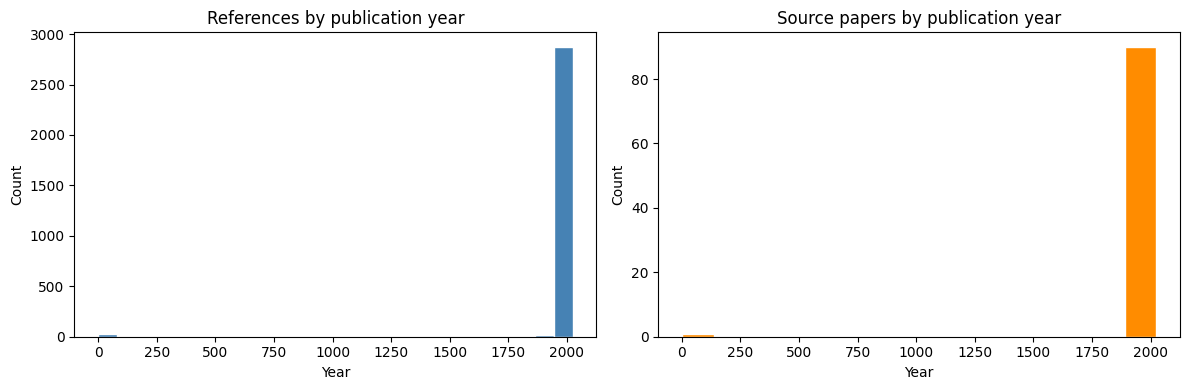

In [18]:
import matplotlib.pyplot as plt

ref_years   = g.references["Year"].dropna().astype(int)
paper_years = g.papers["Year"].dropna().astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(ref_years,   bins=25, color="steelblue",  edgecolor="white")
ax1.set_title("References by publication year")
ax1.set_xlabel("Year"); ax1.set_ylabel("Count")

ax2.hist(paper_years, bins=15, color="darkorange", edgecolor="white")
ax2.set_title("Source papers by publication year")
ax2.set_xlabel("Year"); ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Most-cited authors

Use the canonical authors produced by Stage 6. A naïve `references["Authors"].str.split(",")` would count initials like "J.", "M.", "E." as authors of their own (the `Authors` field is a comma-joined display string, not a list — splitting it conflates "Smith, J., Doe, M." into four tokens). Stage 6 fixes this by parsing each name into a structured surname + given form and clustering across the corpus.

In [ ]:
# Re-instantiate g so it picks up authors.csv / author_citations.csv that
# Stage 6 wrote (the earlier `g` was built before Stage 6 ran).
g = CitationGraph.from_out_dir(OUT_DIR)
print(g)  # repr now includes the author count
g.top_cited_authors(15)

In [ ]:
# Diacritic-insensitive substring lookup on surname or display name.
# Returns the matching canonical authors sorted by citation count.
g.find_author("cardenas")

In [ ]:
# Pick the top Cardenas hit and list the references where they were cited
# in this corpus, alongside the source paper that did the citing.
juan_id = g.find_author("cardenas").index[0]
g.citations_of(juan_id).head(15)

In [21]:
cited

,Authors,Journal,Title,Year,citation_count
id,,,,,
r-ostrom-1994-rules-games-and-common-pool-resources,"Ostrom, Elinor, Roy Gardner, James Walker",Ann Arbor: University of Michigan Press,"Rules, Games, and Common-Pool Resources.",1994,27
r-ledyard-1995-public-goods-a-survey-of-experimental,"Ledyard, John O.","The Handbook of Experimental Economics, ed. Jo...",Public Goods: A Survey of Experimental Research.,1995,27
r-cardenas-2000-local-environmental-control-and-crowding,"Cardenas, Juan-Camilo, Stranlund, John K., Wil...",World Development,Local Environmental Control and Institutional ...,2000,26
r-ostrom-1990-governing-the-commons-the-evolution-of,"Ostrom, Elinor",Cambridge University Press,Governing the Commons: The evolution of instit...,1990,23
r-ostrom-1998-a-behavioral-approach-to-the-rational-of,"Ostrom, Elinor",American Political Science Review,A Behavioral Approach to the Rational Choice T...,1998,22
...,...,...,...,...,...
r-chen-2016-otree-an-open-source-platform-for-online,"Chen, D. L., Schonger, M., Wickens, C.",Journal of Behavioral and Experimental Finance,"oTree-an open-source platform for laboratory, ...",2016,1
r-dean-2019-the-empirical-relationship-between,"Dean, M., Ortoleva, P.",Proceedings of the National Academy of Sciences,The empirical relationship between nonstandard...,2019,1
r-dinno-2017-tostregress-linear-regression-tests-for,"Dinno, A.",Stata software package,tostregress: Linear regression tests for equiv...,2017,1


### NetworkX — graph metrics

Export to a `networkx.DiGraph` for degree and centrality analysis.
Requires `pip install networkx`.

In [20]:
import networkx as nx
import pandas as pd

G = g.to_networkx()

in_deg  = pd.Series(dict(G.in_degree()),  name="in_degree")
out_deg = pd.Series(dict(G.out_degree()), name="out_degree")
pr      = pd.Series(nx.pagerank(G, alpha=0.85), name="pagerank")

metrics = pd.concat([in_deg, out_deg, pr], axis=1)
metrics.sort_values("pagerank", ascending=False).head(15)

,in_degree,out_degree,pagerank
r-ostrom-1994-rules-games-and-common-pool-resources,27,0,0.000561
r-cardenas-2000-local-environmental-control-and-crowding,26,0,0.000549
r-ledyard-1995-public-goods-a-survey-of-experimental,27,0,0.000541
r-ostrom-1998-a-behavioral-approach-to-the-rational-of,22,0,0.000507
r-ostrom-1990-governing-the-commons-the-evolution-of,23,0,0.000506
r-harrison-2004-field-experiments,22,0,0.000485
r-ostrom-2000-collective-action-and-the-evolution-of,15,0,0.000461
r-hardin-1968-the-tragedy-of-the-commons,15,0,0.000459
r-cardenas-2003-real-wealth-and-experimental-cooperation,14,0,0.000437
r-cardenas-2002-economic-inequality-and-burden-sharing,11,0,0.000433
